In [11]:
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import textwrap
import os

In [12]:
path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")

In [13]:
df = pd.read_csv(path + os.sep + "RAW_recipes.csv")
df

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8
...,...,...,...,...,...,...,...,...,...,...,...,...
231632,zydeco soup,486161,60,227978,2012-08-29,"['ham', '60-minutes-or-less', 'time-to-make', ...","[415.2, 26.0, 34.0, 26.0, 44.0, 21.0, 15.0]",7,"['heat oil in a 4-quart dutch oven', 'add cele...",this is a delicious soup that i originally fou...,"['celery', 'onion', 'green sweet pepper', 'gar...",22
231633,zydeco spice mix,493372,5,1500678,2013-01-09,"['15-minutes-or-less', 'time-to-make', 'course...","[14.8, 0.0, 2.0, 58.0, 1.0, 0.0, 1.0]",1,['mix all ingredients together thoroughly'],this spice mix will make your taste buds dance!,"['paprika', 'salt', 'garlic powder', 'onion po...",13
231634,zydeco ya ya deviled eggs,308080,40,37779,2008-06-07,"['60-minutes-or-less', 'time-to-make', 'course...","[59.2, 6.0, 2.0, 3.0, 6.0, 5.0, 0.0]",7,"['in a bowl , combine the mashed yolks and may...","deviled eggs, cajun-style","['hard-cooked eggs', 'mayonnaise', 'dijon must...",8
231635,cookies by design cookies on a stick,298512,29,506822,2008-04-15,"['30-minutes-or-less', 'time-to-make', 'course...","[188.0, 11.0, 57.0, 11.0, 7.0, 21.0, 9.0]",9,['place melted butter in a large mixing bowl a...,"i've heard of the 'cookies by design' company,...","['butter', 'eagle brand condensed milk', 'ligh...",10


In [14]:
df2 = pd.read_csv(path + os.sep + "RAW_interactions.csv")
df2

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."
...,...,...,...,...,...
1132362,116593,72730,2003-12-09,0,Another approach is to start making sauce with...
1132363,583662,386618,2009-09-29,5,These were so delicious! My husband and I tru...
1132364,157126,78003,2008-06-23,5,WOW! Sometimes I don't take the time to rate ...
1132365,53932,78003,2009-01-11,4,Very good! I used regular port as well. The ...


In [15]:
df3 = pd.DataFrame()
groups = df2.groupby("recipe_id")
df3["avg_rating"] = groups["rating"].mean()
df3["rating_count"] = groups["rating"].count()
df3 = df3[df3["rating_count"] >= 100]
df3 = df3.sort_values("avg_rating", ascending=False).head(10)
df3

,avg_rating,rating_count
recipe_id,,
486261,4.990783,217
42976,4.915254,118
92072,4.865672,134
100526,4.848921,139
216350,4.847328,131
38846,4.846154,117
73488,4.844444,135
93223,4.840000,100
104975,4.836066,122


In [19]:
lookup = df.set_index("id")["name"]

df3["name"] = df3.index.map(lookup)
df3.to_csv("top_10_recipes_foodcom.csv")
df3

,avg_rating,rating_count,name
recipe_id,,,
486261,4.990783,217,mexican stack up rsc
42976,4.915254,118,brown sugar bundt cake
92072,4.865672,134,monterey chicken rolls
100526,4.848921,139,sweet creamy coleslaw
216350,4.847328,131,linda s cheesecake stuffed strawberries
38846,4.846154,117,spiced sweet roasted red pepper feta hummus
73488,4.844444,135,individual cream cheese danish
93223,4.840000,100,croutons
104975,4.836066,122,easy festive chocolate holiday pretzels


In [20]:
df4 = pd.read_csv("top_10_recipes_foodcom_fixed.csv")
df4["name_wrapped"] = df4["name"].apply(lambda x: "\n".join(textwrap.wrap(x, width=30)))
df4

,recipe_id,avg_rating,rating_count,name,name_wrapped
0,486261,4.990783,217,Mexican Stack-Up #RSC,Mexican Stack-Up #RSC
1,42976,4.915254,118,Brown Sugar Bundt Cake,Brown Sugar Bundt Cake
2,92072,4.865672,134,Monterey Chicken Rolls,Monterey Chicken Rolls
3,100526,4.848921,139,"Sweet, Creamy Coleslaw","Sweet, Creamy Coleslaw"
4,216350,4.847328,131,Linda's Cheesecake Stuffed Strawberries,Linda's Cheesecake Stuffed\nStrawberries
5,38846,4.846154,117,Spiced Sweet Roasted Red Pepper & Feta Hummus,Spiced Sweet Roasted Red\nPepper & Feta Hummus
6,73488,4.844444,135,Individual Cream Cheese Danish,Individual Cream Cheese Danish
7,93223,4.840000,100,Croutons,Croutons
8,104975,4.836066,122,"Easy, Festive Chocolate Holiday Pretzels","Easy, Festive Chocolate\nHoliday Pretzels"
9,26451,4.820000,100,White Fish in Herbed Butter,White Fish in Herbed Butter


In [46]:
font_path = "AtkinsonHyperlegibleNext-VariableFont_wght.ttf"
fm.fontManager.addfont(font_path)
props = fm.FontProperties(fname=font_path)

sns.set_theme(font=props.get_name())
print(props.get_name())

fontfam = props.get_name()

plt.rcParams['font.family'] = fontfam
plt.rcParams['font.sans-serif'] = [fontfam]

Atkinson Hyperlegible Next


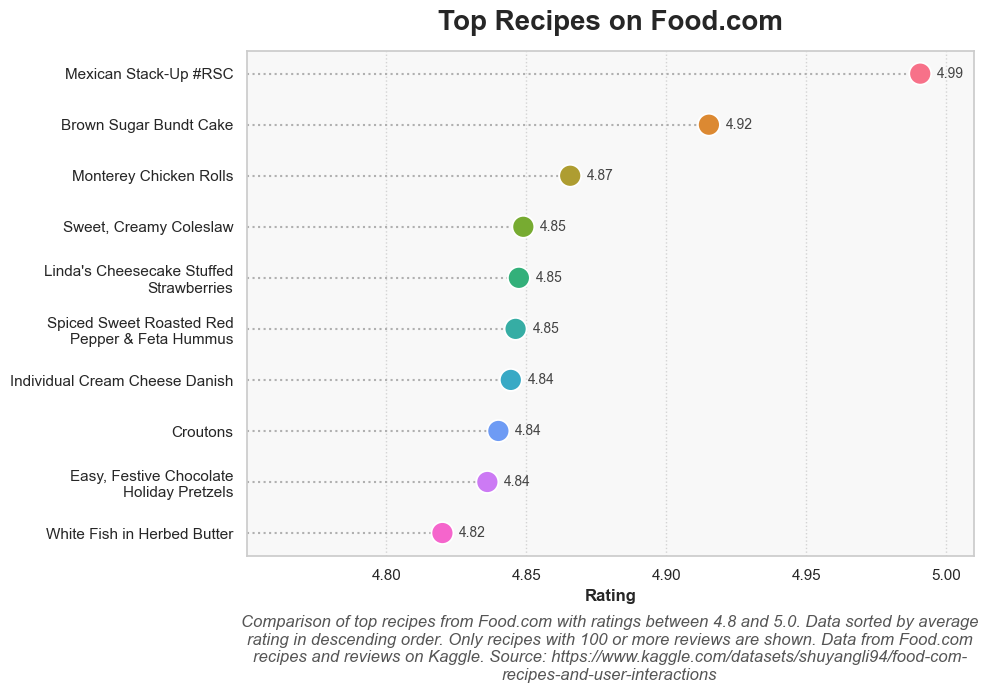

In [144]:
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid", {"axes.grid": False})

cmap = sns.color_palette("husl", n_colors=len(df4))

# horizontal guide lines for the lolipop "stick"
plt.hlines(y=df4["name_wrapped"], xmin=4.75, xmax=df4["avg_rating"], 
           color="#b0b0b0", linestyle=":", linewidth=1.5, zorder=1)

ax = sns.scatterplot(data=df4, x="avg_rating", y="name_wrapped", hue="name_wrapped", palette=cmap, s=250, legend=False, zorder=2)

# set background color
ax.set_facecolor('#f8f8f8')

# x axis
plt.xlim(4.75, 5.01)
plt.xticks([4.80, 4.85, 4.90, 4.95, 5.00])

# vertical lines
plt.grid(axis="x", linestyle=":", color="grey", alpha=0.3, zorder=0)

# numbers for values
for i, (idx, row) in enumerate(df4.iterrows()):
    plt.text(row["avg_rating"] + 0.006, i, f"{row["avg_rating"]:.2f}", 
             va="center", ha="left", fontsize=10, fontweight="book", color="#444444")

plt.title("Top Recipes on Food.com", fontsize=20, pad=15, fontweight="bold")
plt.xlabel("Rating", fontweight="bold")
plt.ylabel("")
plt.tight_layout()

plt.tight_layout(rect=[0, 0.1, 1, 1])

caption = "Comparison of top recipes from Food.com with ratings between 4.8 and 5.0. Data sorted by average rating in descending order. Only recipes with 100 or more reviews are shown. Data from Food.com recipes and reviews on Kaggle. Source: https://www.kaggle.com/datasets/shuyangli94/food-com-\nrecipes-and-user-interactions"
plt.figtext(0.6175, 0.11, caption, wrap=True, horizontalalignment="center", verticalalignment="top", fontsize=12, style='italic', color='#555555')

plt.savefig("food_com_top10_recipes.png", dpi=300)
plt.show()